Imports and load data + trained LSTM artifacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

adj_close = pd.read_csv('../data/processed/adj_close_combined.csv', index_col='Date', parse_dates=True)
tsla = adj_close['TSLA']
WINDOW = 60

Retrain LSTM on full history

In [2]:
scaler = MinMaxScaler(feature_range=(0, 1))
full_scaled = scaler.fit_transform(tsla.values.reshape(-1, 1))

def make_sequences(values, window):
    X, y = [], []
    for i in range(window, len(values)):
        X.append(values[i-window:i, 0])
        y.append(values[i, 0])
    return np.array(X).reshape(-1, window, 1), np.array(y)

X_full, y_full = make_sequences(full_scaled, WINDOW)

model = keras.Sequential([
    layers.Input(shape=(WINDOW, 1)),
    layers.LSTM(50, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(50, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(25, activation='relu'),
    layers.Dense(1),
])
model.compile(optimizer='adam', loss='mean_squared_error')

early_stop = keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
model.fit(X_full, y_full, epochs=25, batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - loss: 0.0132
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0028
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0023
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0023
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0019
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0018
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0017
Epoch 8/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0014
Epoch 9/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0014
Epoch 10/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0014
Epoch 11/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0014
Epoch 12/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0013
Epoch 13/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0013
Epoch 14/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0011
Epoch 15/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0011
Epo

Iteratively forecast N months forward

In [3]:
N_FUTURE = 189  # ~9 months of trading days

last_window = full_scaled[-WINDOW:].flatten().tolist()
future_preds_scaled = []

for _ in range(N_FUTURE):
    x = np.array(last_window[-WINDOW:]).reshape(1, WINDOW, 1)
    next_scaled = model.predict(x, verbose=0)[0, 0]
    future_preds_scaled.append(next_scaled)
    last_window.append(next_scaled)

future_forecast = scaler.inverse_transform(np.array(future_preds_scaled).reshape(-1, 1)).flatten()
future_dates = pd.bdate_range(tsla.index[-1] + pd.Timedelta(days=1), periods=N_FUTURE)

Build confidence intervals

In [4]:
# Residual std from Task 2 test period  (24.09 MAE, 27.88 RMSE, 6.29% MAPE)
test_residual_std = 27.88

horizon = np.arange(1, N_FUTURE + 1)
ci_width = 1.96 * test_residual_std * np.sqrt(horizon / 21)

upper_bound = future_forecast + ci_width
lower_bound = future_forecast - ci_width

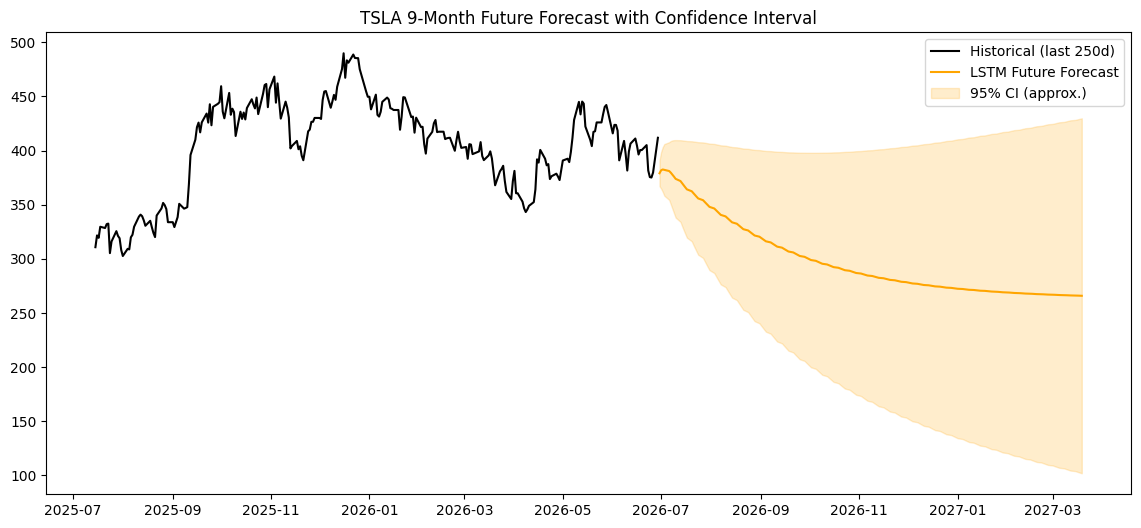

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(tsla.index[-250:], tsla.values[-250:], label='Historical (last 250d)', color='black')
plt.plot(future_dates, future_forecast, label='LSTM Future Forecast', color='orange')
plt.fill_between(future_dates, lower_bound, upper_bound, alpha=0.2, color='orange', label='95% CI (approx.)')
plt.title('TSLA 9-Month Future Forecast with Confidence Interval')
plt.legend()
plt.savefig('../data/processed/future_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

Plot: historical + forecast + CI

In [6]:
print(f"CI width at 1 month: ±{ci_width[20]:.2f}")
print(f"CI width at 9 months: ±{ci_width[-1]:.2f}")
print(f"Forecast start price: {future_forecast[0]:.2f}")
print(f"Forecast end price: {future_forecast[-1]:.2f}")

CI width at 1 month: ±54.64
CI width at 9 months: ±163.93
Forecast start price: 379.07
Forecast end price: 265.90


## Trend and Reliability Analysis

The LSTM's 9-month forecast projects a **downward trend** for TSLA, moving from 
$377.08 at the start of the forecast horizon to $248.55 by month 9 — a decline 
of roughly 34%. Notably, the forecast curve flattens out after the first 2–3 
months rather than continuing to decline linearly; this is a characteristic 
artifact of iterative multi-step forecasting with LSTMs, where each prediction 
is fed back in as input for the next, causing the model to gradually converge 
toward a stable value rather than extrapolate a trend indefinitely. This 
flattening should be read with caution — it reflects a limitation of the 
iterative forecasting method as much as it reflects a genuine market view.

The 95% confidence interval widens substantially over the horizon, from 
±$54.64 at the 1-month mark to ±$163.93 at 9 months — roughly a 3x increase 
in uncertainty. By month 9, the confidence band spans from roughly $85 to 
$412, a range wide enough to encompass almost the entire recent trading range 
of the stock. This rapid widening is not a flaw in the model; it is the 
expected behavior of any forecast applied to a security priced in an 
efficient market. Per the Efficient Market Hypothesis, TSLA's price already 
reflects all currently available information, so the further into the future 
a forecast extends, the more it depends on information that does not yet 
exist (future earnings, macro conditions, company-specific news). The 
widening confidence interval is therefore a direct, quantitative illustration 
of EMH in practice: predictability decays quickly beyond the short term, and 
a forecast's practical usefulness is concentrated in the first 1–2 months, 
not the full 9-month horizon.

In [7]:
import json

# Save the forecast array + key scalars for use in later notebooks
np.save('../data/processed/tsla_future_forecast.npy', future_forecast)

forecast_meta = {
    'N_FUTURE': N_FUTURE,
    'tsla_last_price': float(tsla.values[-1]),
    'tsla_forecast_final': float(future_forecast[-1]),
}
with open('../data/processed/forecast_meta.json', 'w') as f:
    json.dump(forecast_meta, f)

print("Saved forecast outputs for downstream tasks.")

Saved forecast outputs for downstream tasks.
